<a href="https://colab.research.google.com/github/RoihansLab/Machine-Learning-Projects/blob/main/10_End_to_End_Retail_Demand_Forecasting/10_analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Analytic for 10_End_to_End_Retail_Demand_Forecasting.**

## **1. Import Library Module**



In [37]:
#for data
import pandas as pd
import numpy as np
#for visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Visualized standard

In [38]:
plt.figure(figsize = (10,6))
sns.set(style="whitegrid")

<Figure size 1000x600 with 0 Axes>

## **1. Load Datasets**

In [39]:
df = pd.read_csv("/content/demand_forecasting.csv")
df.head(20)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
5,2022-01-01,S001,P0006,Toys,North,209,60,0,35.53,0,Snowy,0,40.01,Winter,0,55
6,2022-01-01,S001,P0007,Groceries,North,118,81,335,23.27,5,Snowy,0,24.78,Winter,0,94
7,2022-01-01,S001,P0008,Electronics,North,244,42,0,37.79,5,Snowy,0,44.85,Winter,0,61
8,2022-01-01,S001,P0009,Clothing,North,115,88,139,94.20,5,Snowy,0,108.70,Winter,0,129
9,2022-01-01,S001,P0010,Furniture,North,192,70,300,113.35,10,Snowy,0,129.98,Winter,0,69


#### check the data

In [40]:
print(df.dtypes)

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition      object
Promotion               int64
Competitor Pricing    float64
Seasonality            object
Epidemic                int64
Demand                  int64
dtype: object


As we can see, the Date column is currently stored as an object (string). We need to convert it into a datetime format to perform time-series analysis.

In [41]:
df["Date"] = pd.to_datetime(df["Date"])

In [42]:
print(df.dtypes)

Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition             object
Promotion                      int64
Competitor Pricing           float64
Seasonality                   object
Epidemic                       int64
Demand                         int64
dtype: object


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[ns]
 1   Store ID            76000 non-null  object        
 2   Product ID          76000 non-null  object        
 3   Category            76000 non-null  object        
 4   Region              76000 non-null  object        
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  object        
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  object    

check is there any NA(Not Availble) values

In [44]:
df.isna().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Price,0
Discount,0


check is there any duplicates

In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Inventory Level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
Promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
Competitor Pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
Epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
Demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


In [47]:
df.describe(include="object").T

,count,unique,top,freq
Store ID,76000,5,S001,15200
Product ID,76000,20,P0001,3800
Category,76000,5,Groceries,30400
Region,76000,4,North,30400
Weather Condition,76000,4,Cloudy,24360
Seasonality,76000,4,Winter,21000


Extracting Time Features: Breaking down the Date column into Year, Month, Day, and Day_of_Week. This step is crucial for helping the model detect seasonal trends and weekly customer buying patterns.

In [48]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

In [49]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64,2024,1,30,Tuesday
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137,2024,1,30,Tuesday
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68,2024,1,30,Tuesday
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84,2024,1,30,Tuesday


In [50]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand', 'Year', 'Month', 'Day', 'Weekday'],
      dtype='object')

In [51]:
df["Discount Price"] = df["Price"] * (1 - df["Discount"] / 100)

In [52]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discount Price
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,0,85.73,Winter,0,115,2022,1,1,Saturday,69.084
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,...,1,92.02,Winter,0,229,2022,1,1,Saturday,68.136
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,...,1,60.08,Winter,0,157,2022,1,1,Saturday,56.646
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,...,0,85.19,Winter,0,52,2022,1,1,Saturday,78.867
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,...,0,51.63,Winter,0,59,2022,1,1,Saturday,54.410
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,...,0,32.23,Winter,0,64,2024,1,30,Tuesday,28.310
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,...,0,40.73,Winter,0,137,2024,1,30,Tuesday,40.774
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,...,0,19.41,Winter,0,68,2024,1,30,Tuesday,16.029
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,...,0,143.71,Winter,0,84,2024,1,30,Tuesday,151.720


In [53]:
df["Sell Through Rate"] = (df["Units Sold"] / df["Inventory Level"])

In [54]:
df["Sell Through Rate"].describe()

,Sell Through Rate
count,75594.000000
mean,0.437580
std,0.298007
min,0.003150
25%,0.190807
50%,0.350475
75%,0.642276
max,1.000000


In [55]:
# Ganti nilai 'inf' (tak terhingga) jadi NaN dulu, baru semua NaN diubah jadi 0
df["Sell Through Rate"] = df["Sell Through Rate"].replace([np.inf, -np.inf], np.nan).fillna(0)

# Cek lagi raport kesehatannya, pastikan count-nya udah balik utuh ke 76000!
df["Sell Through Rate"].describe()

,Sell Through Rate
count,76000.000000
mean,0.435242
std,0.298917
min,0.000000
25%,0.188885
50%,0.348387
75%,0.640625
max,1.000000


In [56]:
df.groupby("Category")["Demand"].agg(["mean", "sum", "std"]).sort_values(by="sum", ascending=False).reset_index()

,Category,mean,sum,std
0,Groceries,120.976447,3677684,48.362730
1,Clothing,112.619737,1369456,41.022968
2,Furniture,73.581140,1006590,32.336141
3,Toys,92.606955,985338,46.170390
4,Electronics,97.482018,889036,40.557859


In [57]:
df.groupby(["Region", "Seasonality"])["Demand"].mean()

Region  Seasonality
East    Autumn         106.353297
        Spring         100.168478
        Summer         115.388315
        Winter         104.273571
North   Autumn         103.065797
        Spring          97.399457
        Summer         112.843750
        Winter         102.017738
South   Autumn         104.464560
        Spring         100.328804
        Summer         115.089946
        Winter         107.733095
West    Autumn         100.165385
        Spring          93.219293
        Summer         108.111141
        Winter         100.988810
Name: Demand, dtype: float64

In [58]:
df.groupby("Promotion")["Demand"].mean()

,Demand
Promotion,
0,95.026843
1,123.269400


In [59]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand', 'Year', 'Month', 'Day', 'Weekday',
       'Discount Price', 'Sell Through Rate'],
      dtype='object')

In [60]:
pd.pivot_table(df, values= "Demand", index = "Month", columns ="Category", aggfunc="mean")

Category,Clothing,Electronics,Furniture,Groceries,Toys
Month,,,,,
1,126.997962,99.519022,75.690821,117.399457,94.242236
2,128.966518,84.184524,61.625992,103.522768,68.885204
3,105.835685,108.120968,84.015233,126.561694,128.273041
4,106.972917,85.916667,63.005556,105.111250,85.753571
5,108.650202,79.577957,56.036738,98.637903,71.756912
6,105.670833,106.922222,79.908333,147.772500,100.825000
7,107.838710,87.418011,66.156810,128.744355,74.366359
8,107.871976,109.733871,83.524194,149.875403,102.794931
9,105.118750,105.015278,81.854630,122.239167,102.722619


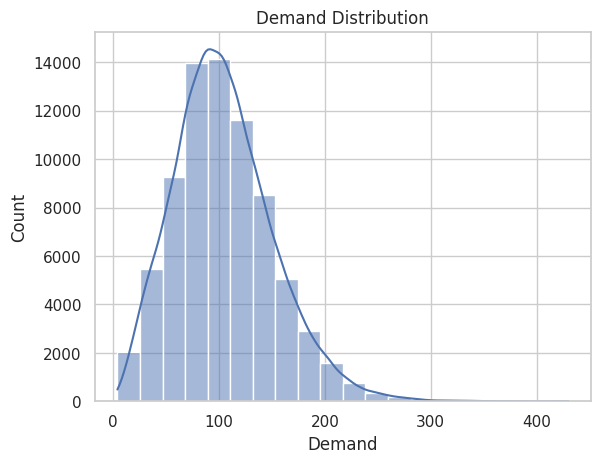

In [65]:
sns.histplot(df["Demand"], bins = 20, kde= True)
plt.title("Demand Distribution")
plt.show()

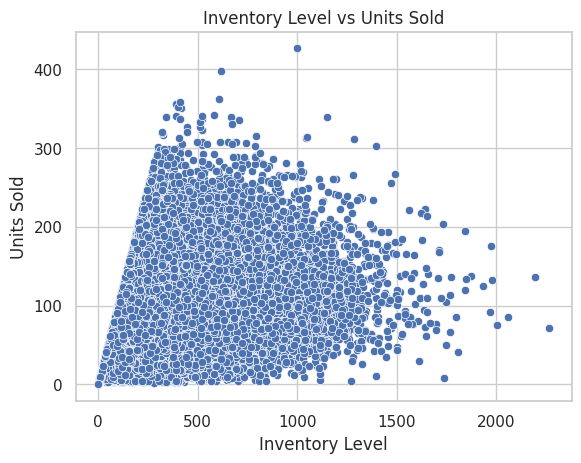

In [68]:
sns.scatterplot(data = df, x = "Inventory Level", y = "Units Sold")
plt.title("Inventory Level vs Units Sold")
plt.show()

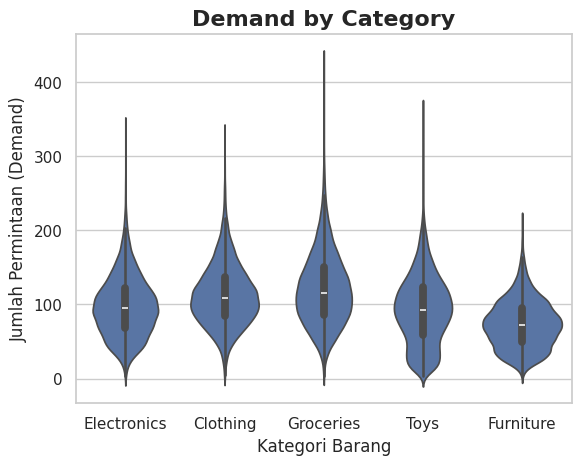

In [69]:
sns.violinplot(data=df, x="Category", y="Demand")

# Kasih judul dan label biar cakep
plt.title("Demand by Category", fontsize=16, fontweight="bold")
plt.xlabel("Kategori Barang", fontsize=12)
plt.ylabel("Jumlah Permintaan (Demand)", fontsize=12)

# Munculin grafiknya
plt.show()

/tmp/ipykernel_12385/2134358986.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Weather Condition", y="Demand", palette="Set2")


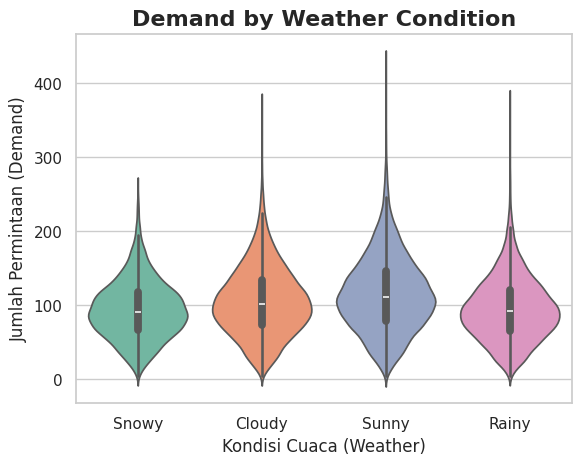

In [70]:
  # Bikin Violin Plot buat Cuaca vs Demand
sns.violinplot(data=df, x="Weather Condition", y="Demand", palette="Set2")

# Kasih judul biar makin pro
plt.title("Demand by Weather Condition", fontsize=16, fontweight="bold")
plt.xlabel("Kondisi Cuaca (Weather)", fontsize=12)
plt.ylabel("Jumlah Permintaan (Demand)", fontsize=12)

# Munculin grafiknya
plt.show()

In [73]:
monthly_demand = df.groupby("Month")["Demand"].mean()

In [74]:
monthly_demand

,Demand
Month,
1,106.040000
2,92.882500
3,113.613871
4,92.816667
5,86.521129
6,117.346000
7,101.561613
8,119.803387
9,107.431500


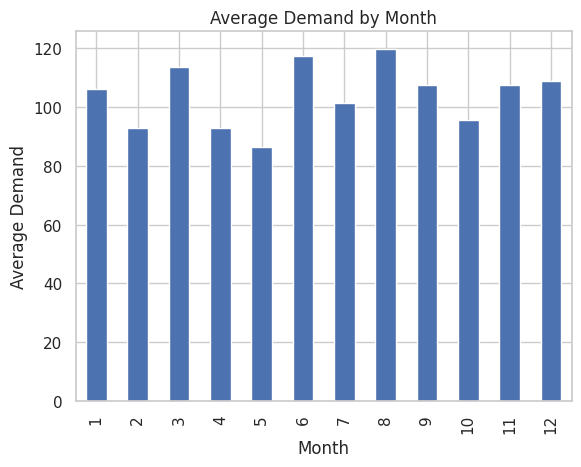

In [75]:
monthly_demand.plot(kind="bar")
plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand")
plt.show()

In [77]:
daily_demand = df.groupby("Date")["Demand"].sum()
daily_demand

,Demand
Date,
2022-01-01,10060
2022-01-02,10814
2022-01-03,11317
2022-01-04,11469
2022-01-05,11724
...,...
2024-01-26,11182
2024-01-27,11540
2024-01-28,11440


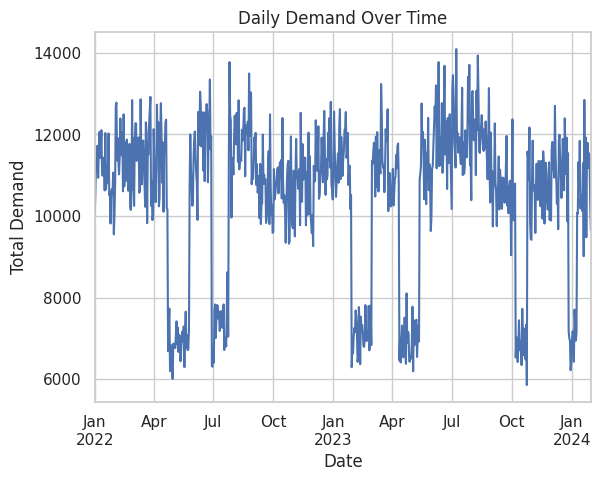

In [78]:
daily_demand.plot()
plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Demand")
plt.show()

In [84]:
promotion_effect = df.groupby("Promotion")["Demand"].sum()
promotion_effect

,Demand
Promotion,
0,4846369
1,3081735


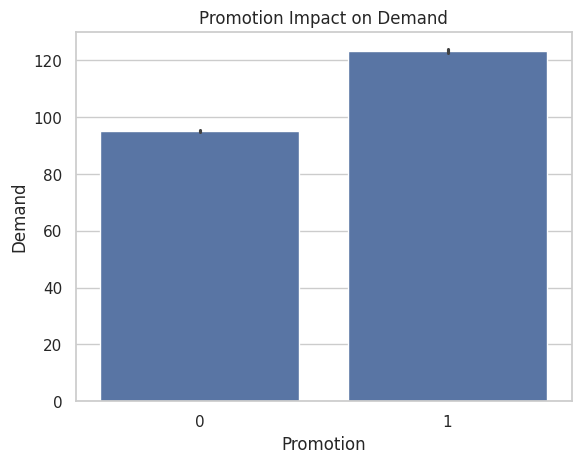

In [86]:
sns.barplot(data= df, x="Promotion", y="Demand")
plt.title("Promotion Impact on Demand")
plt.show()